In [5]:
# Homework Repo Setup

# 1. ENTER your GitHub username (the one that owns your fork)
github_username ="Cipher212"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Ensure we start from /content ---
# This is crucial to prevent nested cloning/directory changes if notebook was previously run
initial_cwd = os.getcwd()
if initial_cwd != "/content":
    os.chdir("/content")
    print(f"🌍 Changed to /content from {initial_cwd}")
else:
    print(f"🌍 Already in /content.")


# --- Handle repo cloning and initial directory change ---
if os.path.exists(repo_name) and os.path.isdir(repo_name):
    # If repo exists, simply change into it from /content
    os.chdir(repo_name)
    print(f"✅ Repo '{repo_name}' already exists. Changed directory to: {os.getcwd()}")
else:
    # If repo does not exist, clone it
    print(f"📥 Cloning repo from {repo_url}...")
    os.system(f"git clone {repo_url}")
    # After cloning, change into the newly created repo directory (which is now in /content)
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found after cloning. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# --- Set Today's Directory ---
today_dir = "Assignments/HW4"
if os.path.exists(today_dir) and os.path.isdir(today_dir):
    os.chdir(today_dir)
    print(f"📂 Changed directory to: {os.getcwd()}")
else:
    print(f"❌ ERROR: Today's directory '{today_dir}' not found relative to {os.getcwd()}.")
    print(f"💡 Please ensure '{today_dir}' exists in your cloned repository.")

🌍 Changed to /content from /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4
✅ Repo 'STAT-7220-Applied-Experimental-Design' already exists. Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Cipher212/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.
*Ans*: To determine if there is a statitical significance in the difference in 100-meter sprint times between carbon-fiber blade Model A and Model B for T64 sprinters.

2.  Specify the outcome variable and how it is measured.
*Ans*: Sprint_time which is the 100 meter sprint in seconds.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?
*Ans*: Our independent variables are Blade Design and Athlete. Lurking variables would be track grip/conditions, weather, fatigue across 3 trials for athletes and comfort/fit of blades on each athlete.

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

*Ans*:  

Fixed effects are for predefined variables that are the focus of the experiment. Random effects are samples from a population that are controlled for in order to measure variance of the fixed effects only.

5.  State the sets of null and alternative hypotheses for this experiment.
*Ans*:

**Blase Design**

Null Hypothesis: There is statistically significant difference in the average sprint times between two blade designs.

Alternative Hypothesis: There is statistically significant difference in the average sprint times between two blade designs.

**Athlete**

Null Hypothesis: There is no statistically sig. difference in sprint times between all athletes

Alternative Hypothesis: There is a statistically sig. difference in sprint times between all athletes


6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

*Ans:* In the boxplot, Aerostep model shows lower mean sprint time with roughly homogenous variance for both treatment groups. Visual separation from Bionic-Flex is quite visible.

Athlete 1 and 2 differ significantly from remaining 3 in terms of average sprint time. Interaction profile consistnetly shows an improvement in run times moving from Bionic Flex to Aerostep.

Overall, the EDA seems to support our null hypothesis for the blade designs, while partially supporting null hypothesis for the athletes having different performance levels.

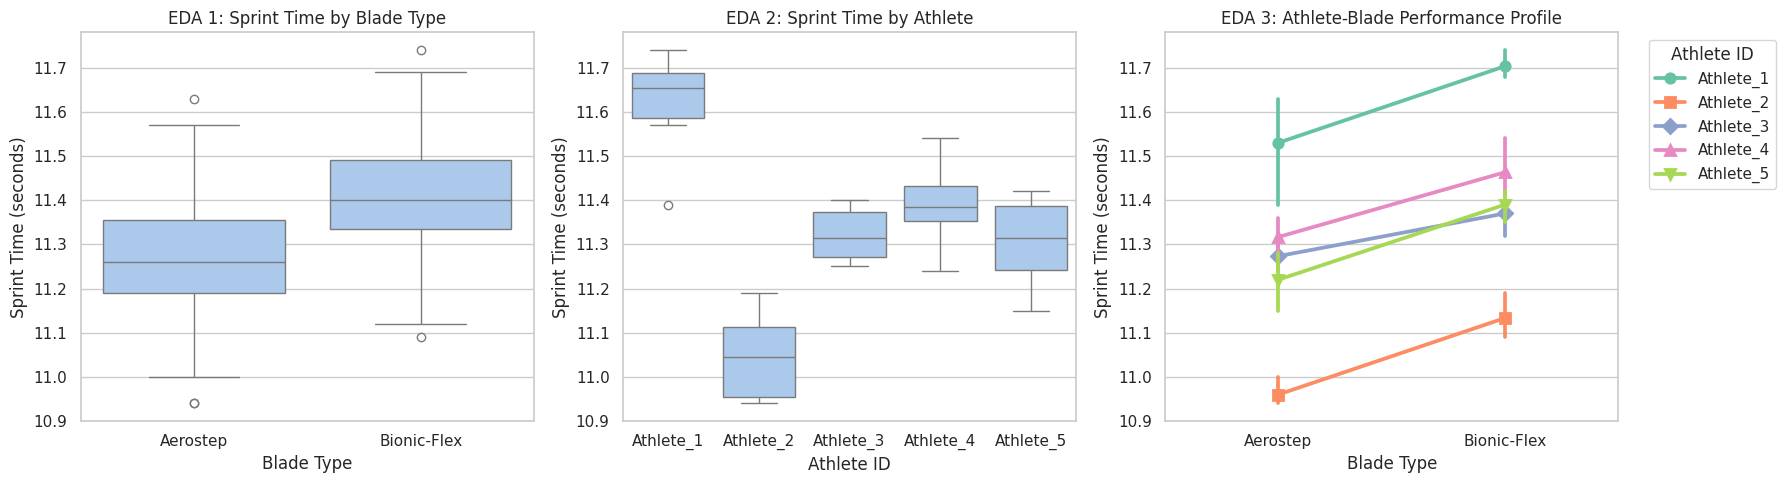

In [7]:
## Question 6 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

# Apply a light, simple prebuilt color theme
sns.set_theme(style="whitegrid", palette="pastel")

# Set up a 1x3 grid for our three EDA plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# EDA 1: Boxplot of Sprint Time by Blade Type
sns.boxplot(data=df, x='Blade_Type', y='Sprint_Time', ax=axes[0])
axes[0].set_title('EDA 1: Sprint Time by Blade Type')
axes[0].set_xlabel('Blade Type')
axes[0].set_ylabel('Sprint Time (seconds)')

# EDA 2: Boxplot of Sprint Time by Athlete
sns.boxplot(data=df, x='Athlete_ID', y='Sprint_Time', ax=axes[1])
axes[1].set_title('EDA 2: Sprint Time by Athlete')
axes[1].set_xlabel('Athlete ID')
axes[1].set_ylabel('Sprint Time (seconds)')

# EDA 3: Interaction/Profile Plot
# (Using Set2 here specifically to keep the distinct athlete lines light but distinguishable)
sns.pointplot(data=df, x='Blade_Type', y='Sprint_Time', hue='Athlete_ID',
              dodge=False, markers=['o', 's', 'D', '^', 'v'], ax=axes[2], palette="Set2")
axes[2].set_title('EDA 3: Athlete-Blade Performance Profile')
axes[2].set_xlabel('Blade Type')
axes[2].set_ylabel('Sprint Time (seconds)')
axes[2].legend(title='Athlete ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

In [ ]:
## Question 7 Code ##

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [ ]:
## Question 9 Code ##

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [ ]:
## Question 10 Code ##

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.